# Gabor orientation decoding — posterior analysis

Loads all TSV variants from `decode_gabor.py` and computes:
- **Circular mean posterior** orientation per trial (π-periodic complex integral)
- **Circular error** (decoded − true, wrapped to [−π/2, π/2])
- **Circular correlation** between decoded and true orientations
- Cross-variant accuracy comparison

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from abstract_values.utils.data import BIDS_FOLDER

In [2]:
# ── helper functions ─────────────────────────────────────────────────────────

def circular_mean_posterior(pdfs):
    """Compute π-periodic circular mean from a posterior DataFrame.

    pdfs : DataFrame (n_trials × n_orientations), columns = orientations in rad.

    Returns a dict with arrays:
      decoded_rad  : circular mean orientation per trial, in [0, π)
      concentration: |z|, the circular concentration ∈ [0, 1]
      circ_std_deg : circular SD in degrees
      z            : raw complex integral
    """
    orientations = pdfs.columns.values.astype(float)
    posterior    = pdfs.values

    norm_factor    = np.trapz(posterior, orientations, axis=1)[:, np.newaxis]
    posterior_norm = posterior / np.where(norm_factor > 0, norm_factor, 1.0)

    z = np.trapz(posterior_norm * np.exp(2j * orientations[np.newaxis, :]),
                 orientations, axis=1)

    decoded_rad   = (np.angle(z) / 2) % np.pi
    concentration = np.abs(z)
    circ_std_deg  = np.rad2deg(np.sqrt(-2 * np.log(concentration.clip(1e-9))))

    return dict(decoded_rad=decoded_rad, concentration=concentration,
                circ_std_deg=circ_std_deg, z=z)


def wrap_pi_half(x):
    """Wrap angle to [−π/2, π/2] (π-periodic circular error)."""
    return (x + np.pi / 2) % np.pi - np.pi / 2


def circular_correlation(x, y):
    """Circular-circular correlation for π-periodic data (Jammalamadaka-SenGupta).

    Uses doubled angles to map [0, π) → [0, 2π) before computing:

        r = Σ sin(2x − 2μx) sin(2y − 2μy)
            ────────────────────────────────────────────────────────
            √[ Σ sin²(2x − 2μx) · Σ sin²(2y − 2μy) ]

    Returns r ∈ [−1, 1].
    """
    x2, y2 = 2 * x, 2 * y
    mu_x2  = np.arctan2(np.mean(np.sin(x2)), np.mean(np.cos(x2)))
    mu_y2  = np.arctan2(np.mean(np.sin(y2)), np.mean(np.cos(y2)))
    dx, dy = np.sin(x2 - mu_x2), np.sin(y2 - mu_y2)
    denom  = np.sqrt(np.sum(dx**2) * np.sum(dy**2))
    return float(np.sum(dx * dy) / denom) if denom > 0 else np.nan

In [3]:
# ── discover all decoding variants ───────────────────────────────────────────
SUBJECT = 'pil01'
SESSION = 1

ses_label  = f'ses-{SESSION}'
decode_dir = (Path(BIDS_FOLDER) / 'derivatives' / 'decoding' / 'gabor'
              / f'sub-{SUBJECT}' / ses_label / 'func')

tsv_files = sorted(decode_dir.glob('*_pars.tsv'))
print(f'Found {len(tsv_files)} variant(s):')
for f in tsv_files:
    print(' ', f.name)

Found 48 variant(s):
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_lambda-0.1_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_lambda-0.2_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_lambda-0.3_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_smoothed_lambda-0.1_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_smoothed_lambda-0.2_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_smoothed_lambda-0.3_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_smoothed_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-spherical_lambda-0.1_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-spherical_lambda-0.2_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-spherical_lambda-0.3_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-spherical_pars.tsv
  sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-spheri

In [4]:
# ── load + decode all variants ───────────────────────────────────────────────
#
# For each TSV: load posteriors, compute circular mean, error, and metrics.
# Results stored in a dict keyed by the filename stem.

all_results = {}

for tsv in tsv_files:
    pdfs = pd.read_csv(tsv, sep='\t',
                       index_col=['session', 'run', 'trial_nr', 'true_orientation_rad'])
    pdfs.columns = pdfs.columns.astype(float)

    stats = circular_mean_posterior(pdfs)
    true_rad    = pdfs.index.get_level_values('true_orientation_rad').values
    decoded_rad = stats['decoded_rad']

    error_rad = wrap_pi_half(decoded_rad - true_rad)
    error_deg = np.rad2deg(error_rad)

    circ_corr = circular_correlation(true_rad, decoded_rad)
    mae        = np.mean(np.abs(error_deg))
    median_ae  = np.median(np.abs(error_deg))

    res = pd.DataFrame({
        'true_rad':       true_rad,
        'decoded_rad':    decoded_rad,
        'true_deg':       np.rad2deg(true_rad),
        'decoded_deg':    np.rad2deg(decoded_rad),
        'error_rad':      error_rad,
        'error_deg':      error_deg,
        'abs_error_deg':  np.abs(error_deg),
        'circ_std_deg':   stats['circ_std_deg'],
        'concentration':  stats['concentration'],
    }, index=pdfs.index)

    all_results[tsv.stem] = dict(
        pdfs=pdfs, results=res, z=stats['z'],
        mae=mae, median_ae=median_ae, circ_corr=circ_corr,
    )
    print(f'{tsv.name}\n'
          f'  MAE={mae:.1f}°  median_AE={median_ae:.1f}°  '
          f'circ_r={circ_corr:.3f}  '
          f'(chance≈45°)\n')

sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_lambda-0.1_pars.tsv
  MAE=34.6°  median_AE=28.5°  circ_r=0.266  (chance≈45°)

sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_lambda-0.2_pars.tsv
  MAE=34.7°  median_AE=28.3°  circ_r=0.243  (chance≈45°)

sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_lambda-0.3_pars.tsv
  MAE=34.8°  median_AE=27.3°  circ_r=0.241  (chance≈45°)

sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_pars.tsv
  MAE=34.9°  median_AE=29.6°  circ_r=-0.338  (chance≈45°)

sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_smoothed_lambda-0.1_pars.tsv
  MAE=32.6°  median_AE=27.4°  circ_r=0.327  (chance≈45°)

sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_smoothed_lambda-0.2_pars.tsv
  MAE=32.5°  median_AE=26.5°  circ_r=0.363  (chance≈45°)

sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_smoothed_lambda-0.3_pars.tsv
  MAE=32.3°  median_AE=26.9°  circ_r=0.348  (chance≈45°)

sub-pil01_ses-1_mask-BensonV1_nvoxels-100_noise-full_smoothed_pars

In [ ]:
# ── comparison table ──────────────────────────────────────────────────────────
def parse_variant(stem, subject, ses_label):
    """Extract mask, noise, smoothed, lambda from output filename stem."""
    s = stem.replace(f'sub-{subject}_{ses_label}_mask-', '')
    mask     = s.split('_')[0]
    noise    = 'spherical' if 'noise-spherical' in stem else 'full'
    smoothed = 'smoothed' if '_smoothed_' in stem + '_' else 'raw'
    m        = re.search(r'_lambda-([0-9.e+\-]+)', stem)
    lambd    = float(m.group(1)) if m else 0.0
    return mask, noise, smoothed, lambd

summary = pd.DataFrame([
    dict(variant=k,
         **dict(zip(['mask', 'noise', 'smoothed', 'lambda'], parse_variant(k, SUBJECT, ses_label))),
         circ_r=v['circ_corr'])
    for k, v in all_results.items()
]).sort_values('circ_r', ascending=False)

display(summary.set_index(['mask', 'noise', 'smoothed', 'lambda'])[['circ_r']].round(3))

In [6]:
summary.head()

,variant,mask,noise,smoothed,lambda,MAE_deg,median_AE_deg,circ_r
21,sub-pil01_ses-1_mask-BensonV2_nvoxels-100_nois...,BensonV2,full,smoothed,0.2,29.806343,23.013378,0.334672
22,sub-pil01_ses-1_mask-BensonV2_nvoxels-100_nois...,BensonV2,full,smoothed,0.3,29.825681,23.447214,0.337019
20,sub-pil01_ses-1_mask-BensonV2_nvoxels-100_nois...,BensonV2,full,smoothed,0.1,29.901272,22.850338,0.293902
27,sub-pil01_ses-1_mask-BensonV2_nvoxels-100_nois...,BensonV2,spherical,raw,0.0,30.109147,23.855924,0.194297
26,sub-pil01_ses-1_mask-BensonV2_nvoxels-100_nois...,BensonV2,spherical,raw,0.3,30.109147,23.855924,0.194297


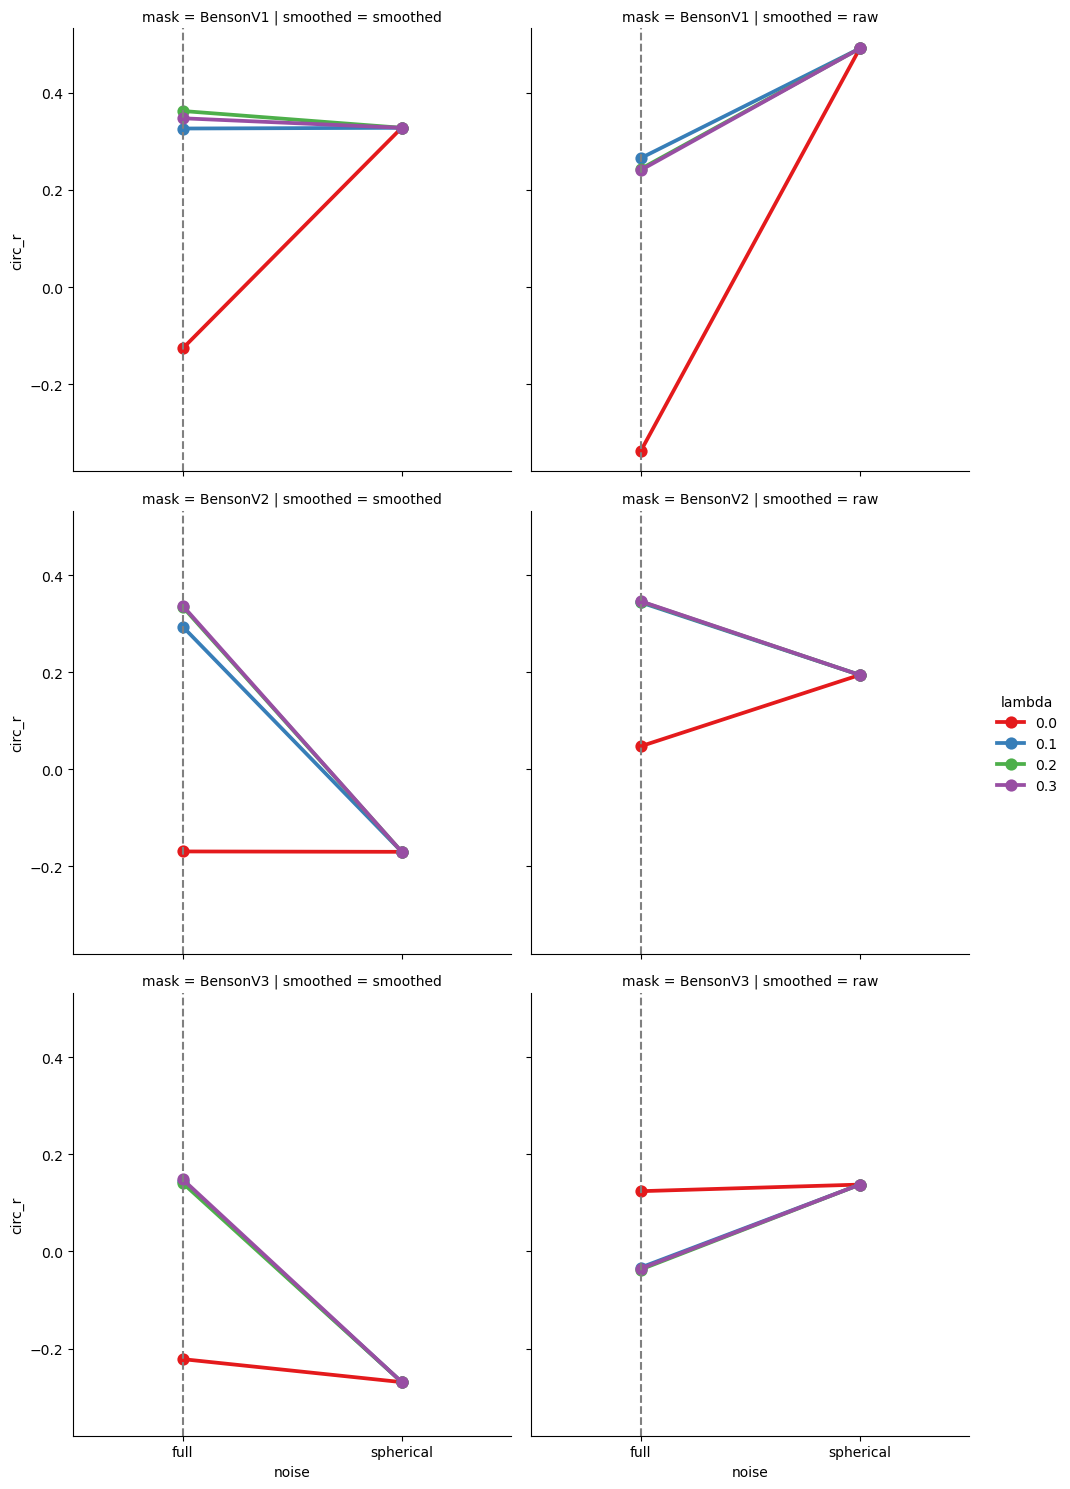

In [7]:
g = sns.catplot(data=summary, x='noise', y='circ_r', col='smoothed', hue='lambda', row='mask', palette='Set1', row_order=['BensonV1', 'BensonV2', 'BensonV3'], kind='point')

g.map(plt.axvline, x=0, color='gray', linestyle='--')

Best variant: sub-pil01_ses-1_mask-BensonV2_nvoxels-100_noise-full_smoothed_lambda-0.2_pars
  MAE  = 29.8°   median |error| = 23.0°   circ r = 0.335


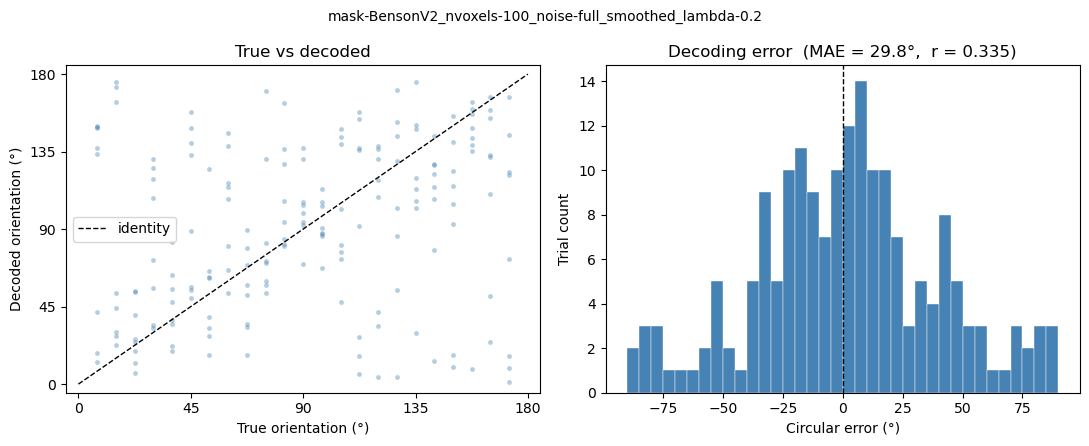

In [8]:
# ── detailed plots for the best variant ──────────────────────────────────────
best_key = summary.iloc[0]['variant']   # lowest MAE
v = all_results[best_key]
results = v['results']

print(f'Best variant: {best_key}')
print(f'  MAE  = {v["mae"]:.1f}°   median |error| = {v["median_ae"]:.1f}°'
      f'   circ r = {v["circ_corr"]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.scatter(results['true_deg'], results['decoded_deg'],
           alpha=0.4, s=12, color='steelblue', linewidths=0)
ax.plot([0, 180], [0, 180], 'k--', lw=1, label='identity')
ax.set_xlabel('True orientation (°)')
ax.set_ylabel('Decoded orientation (°)')
ax.set_title('True vs decoded')
ax.set_xticks([0, 45, 90, 135, 180])
ax.set_yticks([0, 45, 90, 135, 180])
ax.set_xlim(-5, 185); ax.set_ylim(-5, 185)
ax.legend()

ax = axes[1]
ax.hist(results['error_deg'], bins=36, range=(-90, 90),
        color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel('Circular error (°)')
ax.set_ylabel('Trial count')
ax.set_title(f'Decoding error  (MAE = {v["mae"]:.1f}°,  r = {v["circ_corr"]:.3f})')

fig.suptitle(best_key.replace('sub-pil01_ses-1_', '').replace('_pars', ''), fontsize=10)
fig.tight_layout()
plt.show()

Median posterior width: 28.3°


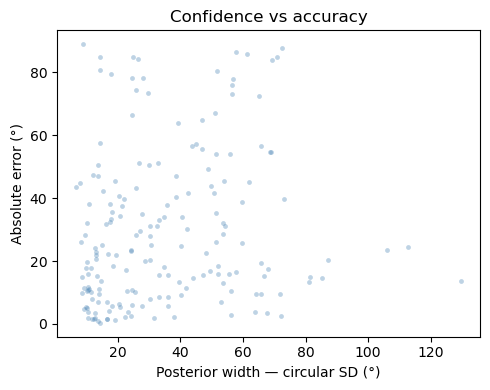

In [9]:
# ── posterior width vs accuracy ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(results['circ_std_deg'], results['abs_error_deg'],
           alpha=0.35, s=12, color='steelblue', linewidths=0)
ax.set_xlabel('Posterior width — circular SD (°)')
ax.set_ylabel('Absolute error (°)')
ax.set_title('Confidence vs accuracy')
print(f'Median posterior width: {results["circ_std_deg"].median():.1f}°')
fig.tight_layout()
plt.show()

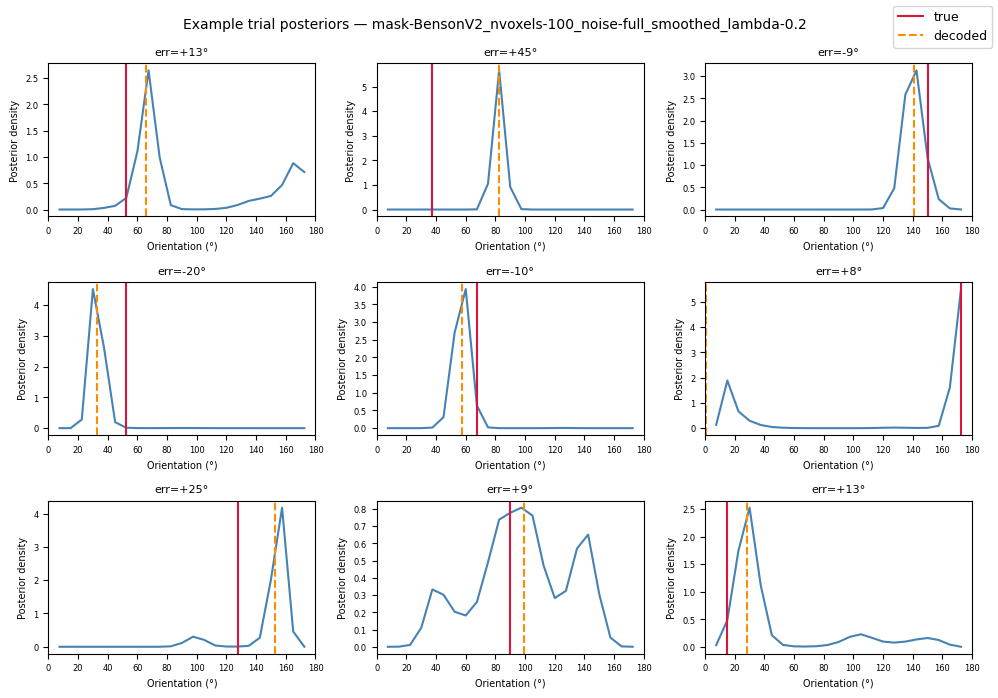

In [10]:
# ── example trial posteriors ─────────────────────────────────────────────────
pdfs_best   = v['pdfs']
orientations = pdfs_best.columns.values.astype(float)

N_EXAMPLES = 9
rng = np.random.default_rng(0)
example_idx = rng.choice(len(pdfs_best), size=N_EXAMPLES, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(10, 7), sharey=False)
for ax, i in zip(axes.ravel(), example_idx):
    row = pdfs_best.iloc[i].values.astype(float)
    p   = row / np.trapz(row, orientations)
    ax.plot(np.rad2deg(orientations), p, color='steelblue')
    ax.axvline(np.rad2deg(results['true_rad'].iloc[i]),
               color='crimson', lw=1.5, label='true')
    ax.axvline(np.rad2deg(results['decoded_rad'].iloc[i]),
               color='darkorange', lw=1.5, ls='--', label='decoded')
    ax.set_xlim(0, 180)
    ax.set_xlabel('Orientation (°)', fontsize=7)
    ax.set_ylabel('Posterior density', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_title(f'err={results["error_deg"].iloc[i]:+.0f}°', fontsize=8)

handles = [
    plt.Line2D([0], [0], color='crimson',    lw=1.5, label='true'),
    plt.Line2D([0], [0], color='darkorange', lw=1.5, ls='--', label='decoded'),
]
fig.legend(handles=handles, loc='upper right', fontsize=9)
fig.suptitle('Example trial posteriors — ' +
             best_key.replace('sub-pil01_ses-1_', '').replace('_pars', ''),
             fontsize=10)
fig.tight_layout()
plt.show()